In [4]:
import sys
from pathlib import Path

root = Path.cwd().parent
if str(root) not in sys.path:
    sys.path.append(str(root))

import pandas as pd
from script.data_loader import ECGLoader
from script.dataset import ECGDataset

# paths
brugada_data = root / "brugada-data"

# load metadata
metadata = pd.read_csv(brugada_data / "metadata.csv")

# init loader + dataset
loader = ECGLoader(brugada_data)
dataset = ECGDataset(metadata, loader)

In [5]:
metadata_filtered = metadata[metadata["brugada"].isin([0, 1])]

print("Total samples:", len(metadata_filtered))
print(metadata_filtered["brugada"].value_counts())

Total samples: 356
brugada
0    287
1     69
Name: count, dtype: int64


In [6]:
available_patients = set(loader.get_available_patients())
metadata_patients = set(metadata_filtered["patient_id"].astype(str))

print("In metadata but missing files:", len(metadata_patients - available_patients))
print("In files but missing metadata:", len(available_patients - metadata_patients))

In metadata but missing files: 0
In files but missing metadata: 7


In [8]:
sample_ids = dataset.get_patient_ids()[:5]

for pid in sample_ids:
    signals, label = dataset.get_sample(pid)
    print(f"Patient {pid} | shape: {signals.shape} | label: {label}")

Patient 188981 | shape: (12, 1200) | label: 1
Patient 251972 | shape: (12, 1200) | label: 0
Patient 265715 | shape: (12, 1200) | label: 0
Patient 267628 | shape: (12, 1200) | label: 0
Patient 267630 | shape: (12, 1200) | label: 1


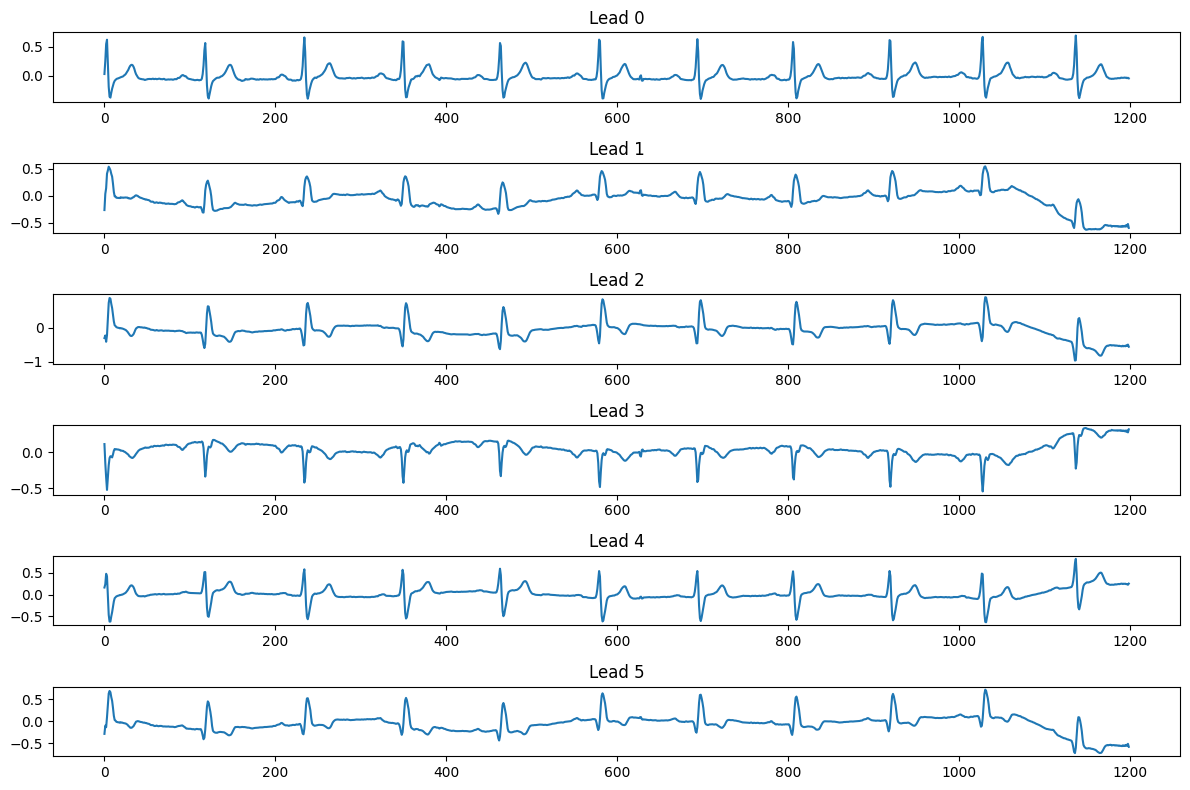

In [9]:
import matplotlib.pyplot as plt

signals, label = dataset.get_sample(sample_ids[0])

plt.figure(figsize=(12, 8))

for i in range(6):  # first 6 leads
    plt.subplot(6, 1, i+1)
    plt.plot(signals[i])
    plt.title(f"Lead {i}")

plt.tight_layout()
plt.show()

In [10]:
# one healthy vs one brugada
healthy_id = metadata_filtered[metadata_filtered["brugada"] == 0]["patient_id"].astype(str).iloc[0]
brugada_id = metadata_filtered[metadata_filtered["brugada"] == 1]["patient_id"].astype(str).iloc[0]

h_signal, _ = dataset.get_sample(healthy_id)
b_signal, _ = dataset.get_sample(brugada_id)

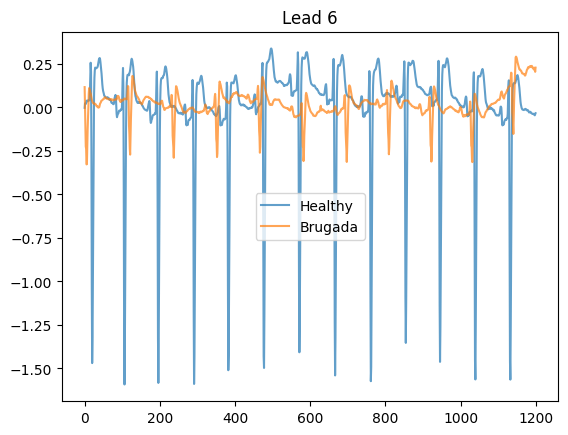

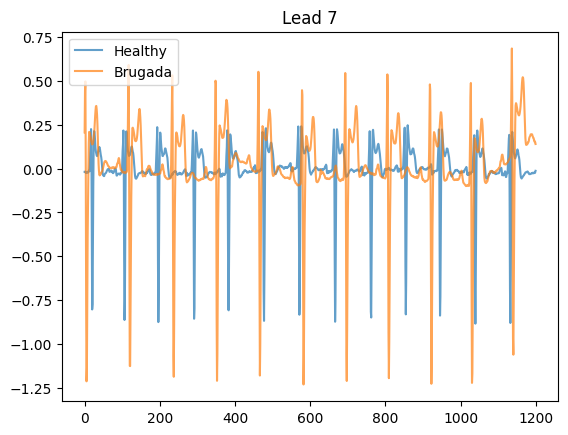

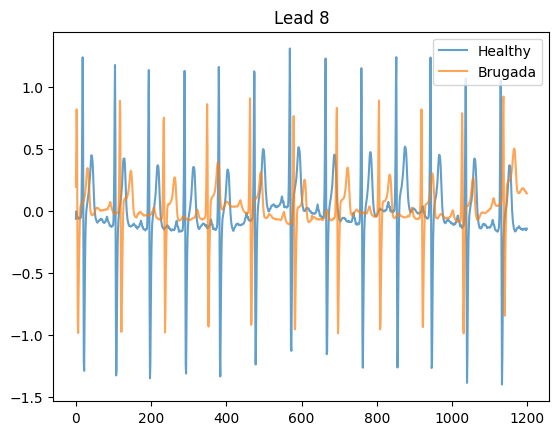

In [11]:
for i in range(6, 9):  # V1–V3 approx index
    plt.plot(h_signal[i], label="Healthy", alpha=0.7)
    plt.plot(b_signal[i], label="Brugada", alpha=0.7)
    plt.title(f"Lead {i}")
    plt.legend()
    plt.show()